# Project B – Deep Ritz Method for 2D Darcy Flow in Heterogeneous Porous Media

**Method:** Deep Ritz method (energy minimisation) with hard Dirichlet boundary conditions.

We solve the Darcy flow equation
$$-\nabla\cdot\big(\mu(x)\nabla u(x)\big) = f = 0,\qquad x\in\Omega=[0,1]^2,$$
with $u=1$ on the left edge, $u=0$ on the right edge, and a linear interpolation
$u=1-x_1$ on the top and bottom edges.

The permeability field $\mu(x)$ is a piecewise constant $128\times128$ pixel map
(two phases: $\mu=10$ and $\mu=2$), provided in the dataset.

**Reference:** The Deep Ritz method is introduced in Lecture 7. The implementation
follows the course exercises on variational problems (e.g., 1D Darcy flow with
Gaussian quadrature).

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt
import h5py
import time
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Paths
script_dir = os.path.abspath('')               # project_B/
project_root = os.path.dirname(script_dir)      # dl-pdes-tum-project/
data_path = os.path.join(project_root, 'data', 'ProblemB_dataset.h5')
output_dir = os.path.join(script_dir, 'Results_ProjectB')
os.makedirs(output_dir, exist_ok=True)

# Load dataset
with h5py.File(data_path, 'r') as f:
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=dtype).to(device)  # (128,128)
    x_test = torch.tensor(np.array(f['x_test']), dtype=dtype).to(device)       # (16384,2)
    u_test = torch.tensor(np.array(f['u_test']), dtype=dtype).to(device)       # (128,128)

u_test_flat = u_test.reshape(-1, 1)   # (16384,1)

print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)

x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])


In [4]:
def fun_mu(x, mu=mu_field, resolution=128):
    """
    Evaluate the permeability field at arbitrary points x.
    Uses nearest‑neighbour lookup from the 128x128 pixel grid.
    """
    delta = 1.0 / (resolution - 1)
    x_loc = torch.floor(x[..., 0] / delta + 0.5).long()
    y_loc = torch.floor(x[..., 1] / delta + 0.5).long()
    loc = y_loc * resolution + x_loc
    mu_flat = mu.reshape(1, -1).to(x.device)
    return mu_flat[0, loc].unsqueeze(-1)

## Step 1: Quadrature and Energy Functional

The Deep Ritz method minimises the energy functional
$$\mathcal{E}(u) = \int_\Omega \frac12 \mu(x) |\nabla u(x)|^2 \,dx.$$

We discretise the integral with a **2D Gauss–Legendre quadrature** rule
(200 points per direction, 40,000 total points), following the course exercise
on 1D Darcy flow. This gives a deterministic, highly accurate approximation.

In [5]:
# 2D Gauss-Legendre quadrature (200 points per dimension)
N_quad = 200
quad_pts_1d, quad_wts_1d = np.polynomial.legendre.leggauss(N_quad)
# Map from [-1,1] to [0,1]
quad_pts_1d = 0.5 * (quad_pts_1d + 1)
quad_wts_1d = 0.5 * quad_wts_1d

# Tensor product for 2D
X_grid, Y_grid = np.meshgrid(quad_pts_1d, quad_pts_1d, indexing='ij')
W_grid = np.outer(quad_wts_1d, quad_wts_1d)

# Flatten and convert to torch (on GPU)
x_int = torch.tensor(np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1), dtype=dtype).to(device)
w_int = torch.tensor(W_grid.ravel(), dtype=dtype).to(device).view(-1, 1)

print(f'Integration points: {x_int.shape[0]}')

Integration points: 40000


## Step 2: Hard Enforcement of Dirichlet Boundary Conditions

The boundary conditions are inhomogeneous and complex:
- $x_1=0$ (left) : $u=1$
- $x_1=1$ (right): $u=0$
- $x_2=0,1$ (top/bottom): $u=1-x_1$

We incorporate them **exactly** into the network ansatz via a lift function
and a distance function that vanishes on the boundary:

$$u_\theta(x) = \underbrace{1-x_1}_{\text{lift}} \;+\; \underbrace{x_1(1-x_1)\,x_2(1-x_2)}_{\text{distance }d(x)} \cdot \mathrm{NN}_\theta(x)$$

This guarantees that $u_\theta$ satisfies all Dirichlet BCs automatically,
so **no boundary penalty term** is needed in the loss.

In [6]:
# Deep MLP with tanh activation (same architecture as used in the course)
class DeepMLP(nn.Module):
    def __init__(self, layers_list):
        super().__init__()
        layers = []
        in_dim = layers_list[0]
        for out_dim in layers_list[1:-1]:
            layers.append(nn.Linear(in_dim, out_dim, dtype=dtype))
            layers.append(nn.Tanh())
            in_dim = out_dim
        self.hidden = nn.Sequential(*layers)
        self.out = nn.Linear(in_dim, layers_list[-1], dtype=dtype)

    def forward(self, x):
        x = self.hidden(x)
        return self.out(x)

# 8 hidden layers, 128 neurons each
nn_model = DeepMLP([2, 128, 128, 128, 128, 128, 128, 128, 128, 1]).to(device)

# Hard BC ansatz
def distance(x):
    return x[:, 0:1] * (1 - x[:, 0:1]) * x[:, 1:2] * (1 - x[:, 1:2])

def u_net(x):
    lift = 1.0 - x[:, 0:1]
    return lift + distance(x) * nn_model(x)

## Step 3: Energy Loss

The loss is simply the discretised energy functional.
Because the boundary conditions are already satisfied exactly by the ansatz,
**no additional terms** are required.

In [7]:
def energy_loss():
    """Evaluate the energy functional on the fixed quadrature grid."""
    x_int.requires_grad_(True)
    u = u_net(x_int)
    mu_val = fun_mu(x_int)
    # Gradient w.r.t. spatial coordinates
    du = grad(u, x_int, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    energy_density = 0.5 * mu_val * (du[:, 0:1]**2 + du[:, 1:2]**2)
    return torch.sum(energy_density * w_int)   # weighted sum = integral

## Step 4: Training

- **Optimiser:** Adam (lr = $10^{-3}$, weight decay = $10^{-4}$)
- **Scheduler:** StepLR (step size = 1000, $\gamma = 0.5$)
- **Epochs:** 10,000
- **Fine‑tuning:** L‑BFGS (500 iterations) after Adam

We record the energy loss (training objective) every epoch and the L² test error
every 500 epochs.

In [8]:
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.5)

epochs = 10000
error_history = []       # test L2 error (recorded every 500 epochs)
energy_history = []      # energy loss (every epoch)
time_history = []        # time per epoch

print("Training Deep Ritz (tanh, high‑order quadrature)...")
for epoch in range(epochs):
    t0 = time.time()

    L = energy_loss()

    optimizer.zero_grad()
    L.backward()
    optimizer.step()
    scheduler.step()

    time_history.append(time.time() - t0)
    energy_history.append(L.item())   # training loss

    if (epoch + 1) % 500 == 0:
        with torch.no_grad():
            u_pred = u_net(x_test)
            err = torch.sqrt(torch.sum((u_pred - u_test_flat)**2) /
                             torch.sum(u_test_flat**2)).item()
            error_history.append(err)
        print(f"Epoch {epoch+1:5d}: energy loss={L.item():.6e}, L2 error={err:.6f}")

Training Deep Ritz (tanh, high‑order quadrature)...
Epoch   500: energy loss=2.156346e+00, L2 error=0.045960
Epoch  1000: energy loss=1.917061e+00, L2 error=0.029620
Epoch  1500: energy loss=1.872675e+00, L2 error=0.029265
Epoch  2000: energy loss=1.865310e+00, L2 error=0.029466
Epoch  2500: energy loss=1.842034e+00, L2 error=0.028716
Epoch  3000: energy loss=1.832860e+00, L2 error=0.028582
Epoch  3500: energy loss=1.825267e+00, L2 error=0.028897
Epoch  4000: energy loss=1.819737e+00, L2 error=0.029269
Epoch  4500: energy loss=1.816231e+00, L2 error=0.029174
Epoch  5000: energy loss=1.812911e+00, L2 error=0.028884
Epoch  5500: energy loss=1.810587e+00, L2 error=0.029424
Epoch  6000: energy loss=1.808357e+00, L2 error=0.029407
Epoch  6500: energy loss=1.806983e+00, L2 error=0.029591
Epoch  7000: energy loss=1.805397e+00, L2 error=0.029650
Epoch  7500: energy loss=1.804468e+00, L2 error=0.029672
Epoch  8000: energy loss=1.803385e+00, L2 error=0.029684
Epoch  8500: energy loss=1.802752e+0

In [9]:
print("Fine‑tuning with L‑BFGS...")
optimizer_lbfgs = torch.optim.LBFGS(nn_model.parameters(), lr=0.5, max_iter=500,
                                    tolerance_grad=1e-9, line_search_fn='strong_wolfe')
def closure():
    optimizer_lbfgs.zero_grad()
    L = energy_loss()
    L.backward()
    return L
optimizer_lbfgs.step(closure)

# Final error after L‑BFGS
with torch.no_grad():
    u_pred = u_net(x_test)
    err_final = torch.sqrt(torch.sum((u_pred - u_test_flat)**2) /
                           torch.sum(u_test_flat**2)).item()
print(f"\nFinal L2 relative error: {err_final:.6f}")

Fine‑tuning with L‑BFGS...

Final L2 relative error: 0.030347


## Results

We visualise the predicted pressure field, the ground truth, the pointwise
absolute error, the convergence of the L² error, and the energy loss history.
All figures are saved in `Results_ProjectB/`.

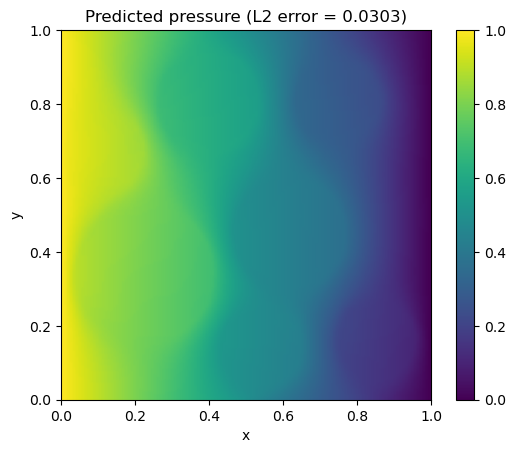

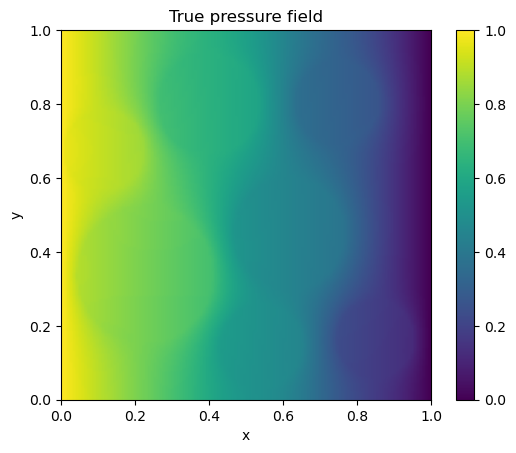

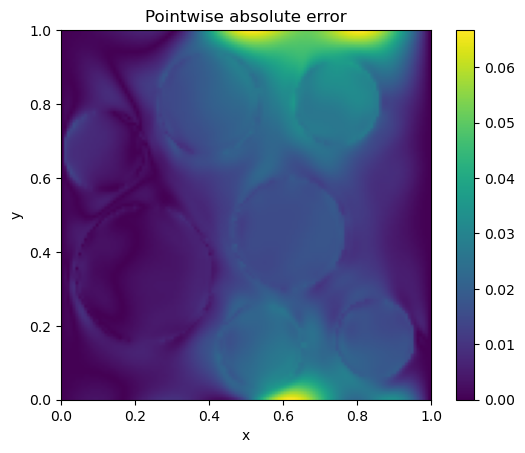

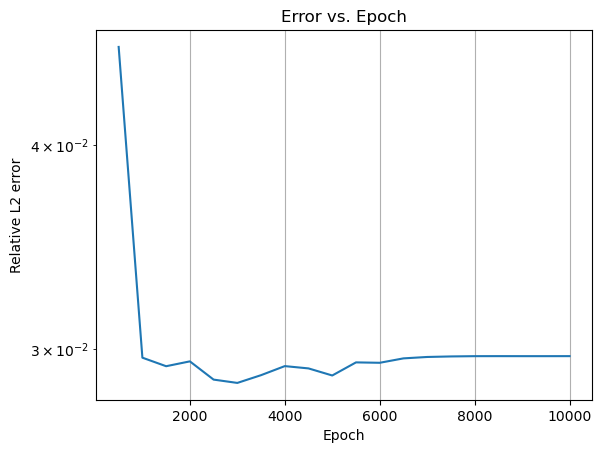

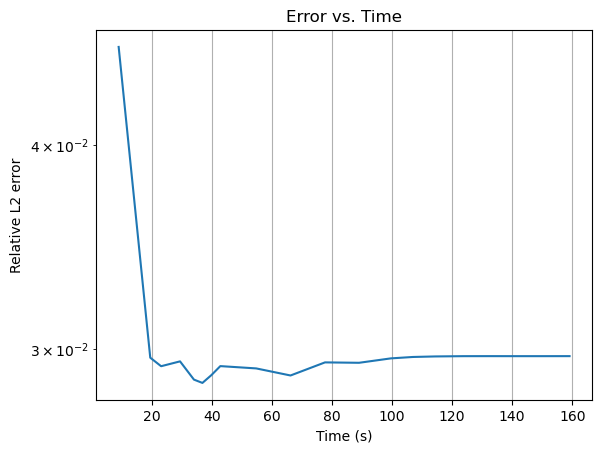

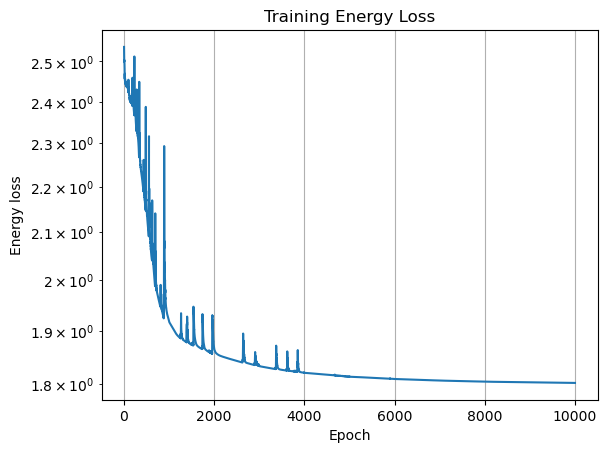

In [10]:
# Reshape predictions for 2D plotting
u_pred_2d = u_pred.cpu().numpy().reshape(128, 128)
u_true_2d = u_test.cpu().numpy()

# 1. Predicted pressure field
plt.figure()
plt.imshow(u_pred_2d, origin='lower', extent=[0,1,0,1])
plt.colorbar()
plt.title(f'Predicted pressure (L2 error = {err_final:.4f})')
plt.xlabel('x'); plt.ylabel('y')
plt.savefig(os.path.join(output_dir, 'u_pred.png'))
plt.show()

# 2. True pressure field
plt.figure()
plt.imshow(u_true_2d, origin='lower', extent=[0,1,0,1])
plt.colorbar()
plt.title('True pressure field')
plt.xlabel('x'); plt.ylabel('y')
plt.savefig(os.path.join(output_dir, 'u_true.png'))
plt.show()

# 3. Pointwise absolute error
abs_err = np.abs(u_pred_2d - u_true_2d)
plt.figure()
plt.imshow(abs_err, origin='lower', extent=[0,1,0,1])
plt.colorbar()
plt.title('Pointwise absolute error')
plt.xlabel('x'); plt.ylabel('y')
plt.savefig(os.path.join(output_dir, 'u_error.png'))
plt.show()

# 4. Error vs. epoch
plt.figure()
plt.plot(range(500, epochs+1, 500), error_history)
plt.xlabel('Epoch'); plt.ylabel('Relative L2 error')
plt.yscale('log')
plt.title('Error vs. Epoch')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'error_vs_epoch.png'))
plt.show()

# 5. Error vs. time
cum_time = np.cumsum(time_history)
eval_times = cum_time[499::500]   # times at recorded epochs
plt.figure()
plt.semilogy(eval_times, error_history)
plt.xlabel('Time (s)'); plt.ylabel('Relative L2 error')
plt.title('Error vs. Time')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'error_vs_time.png'))
plt.show()

# 6. Energy loss (training loss) vs. epoch
plt.figure()
plt.plot(energy_history)
plt.xlabel('Epoch'); plt.ylabel('Energy loss')
plt.yscale('log')
plt.title('Training Energy Loss')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'energy_loss.png'))
plt.show()


The largest errors occur near the sharp interface between the two permeability phases,
as expected for a discontinuous coefficient.

The implementation follows the course lectures and exercises (especially the 1D Darcy
flow with Gaussian quadrature and the 5D Poisson Deep Ritz example). All components
are built from scratch using PyTorch.